# The Canonical Ensemble
In statistical mechanics, an ensemble is a large set of imaginary copies of a system, considered under the same macroscopic conditions. In the canonical ensemble, each system in the ensemble is in thermal contact with a heat reservoir at a fixed temperature $T$ (the system can exchange energy with the environment, but has fixed volume and number of particles). The probability of finding the system in a particular microstate $s$ with energy $E_s$ is given by the Boltzmann distribution:
$$P_s = \frac{e^{-E_s/k_B T}}{Z}$$
where $k_B$ is Boltzmann’s constant and $Z$ is the normalization constant. Since the probabilities must sum to 1,
$$Z = \sum_s e^{-E_s/k_B T}$$
summing over all possible microstates $s$. This quantity $Z$ is called the partition function of the system. It encodes the statistical properties of the system and ensures $P_s$ is properly normalized.

Using the Boltzmann distribution, we can compute ensemble averages of physical quantities. The ensemble average of an observable $A$ is defined as $\langle A \rangle = \sum_s A_s P_s$. In particular, the mean energy is:
$$\langle E\rangle = \sum_s E_s P_s = \frac{1}{Z}E_s e^{-\beta E_s}$$
with $\beta = 1/(k_B T)$. (In these equations, $E_s$ and $A_s$ are the energy and the value of $A$ in microstate $s$.)

## Using The Metropolis algorithm
In practice, for a system with many degrees of freedom, the sum over all microstates is astronomically large and cannot be evaluated directly. We therefore use Monte Carlo methods to estimate ensemble averages by sampling representative states. For a general observable $A$, the exact ensemble average is
$$\langle A\rangle = \frac{1}{Z} \sum_s A_s e^{-\beta E_s}$$
The idea of Monte Carlo sampling is to generate a representative set of $m$ configurations (microstates) and approximate the average by a sample mean:
$$\langle A\rangle \approx \frac{1}{Z} \sum_s^m A_s e^{-\beta E_s}$$
where the sum is over the sampled configurations.

A crude Monte Carlo approach would be to generate configurations completely at random, calculate $A_s e^{-\beta E_s}$ for each, and average. This is equivalent to the “hit-and-miss” method for evaluating integrals. However, this approach is very inefficient because most randomly chosen states have extremely low Boltzmann weight $e^{-\beta E}$ and contribute almost nothing to the average. Instead, we prefer to sample important configurations -those with large $e^{-\beta E_s}$ – more frequently. This strategy is called *importance sampling*. The most convenient choice is to generate configurations with probability proportional to the Boltzmann weight itself $P_s$.

If we sample states with the Boltzmann probability $P_s$, then each sampled state $s$ is already weighted correctly in the average. In that case, the estimator for the ensemble average simplifies to the simple arithmetic mean of the observable over the $m$ sampled configurations:
$$\langle A\rangle \approx \frac{1}{m}\sum_{s=1}^m A_s$$
since each sampled $A_s$ already comes from a Boltzmann-weighted distribution.

To generate sample states with probability $P_s$, we perform a random walk in configuration space using the Metropolis Monte Carlo algorithm. The Monte Carlo procedure constructs a sequence of configurations $i \to j \to \dots$ such that the fraction of time spent in each state corresponds to $P_s$. One way to ensure this is to design the transition probability $W(i\to j)$ between states $i$ and $j$ to satisfy detailed balance:
$$W(i\rightarrow j)e^{-\beta E_i} = W(j\rightarrow i)e^{-\beta E_j}$$
A convenient choice is the Metropolis choice:
$$W(i\rightarrow j) = min\left(1,P_j/P_i\right) = min(1,e^{-\beta(E_j-E_i)})$$
We see that the partition function $Z$ cancels in the ratio $P_j/P_i$, so we don’t need to know it explicitly. Moves that lead to a lower energy ($E_j < E_i$) have $P_j/P_i > 1$, so $W=1$ (always accepted). Moves that increase the energy are accepted with probability $e^{-\beta \Delta E}$, where $\Delta E = E_j - E_i > 0$. (This choice of $W$ is not unique – any transition rule satisfying detailed balance will eventually produce the Boltzmann distribution. For example, another common choice is $W(i\to j) = 1/\left(e^{-\beta (E_j - E_i)} + 1\right)$, which would give $W=1/2$ if $\Delta E=0$.)

Using the Metropolis criterion, we can outline the Monte Carlo simulation algorithm as follows:
1. Establish an initial configuration. This means set the starting values of all degrees of freedom (for example, assign an initial velocity to each particle in a gas, or an initial orientation to each spin in a spin system).
2. Make a random trial change in the configuration. For example, in a spin system you might flip a randomly chosen spin. In our 1D gas example, you could pick one particle at random and modify its velocity by a small random amount.
3. Compute the change in the energy $\Delta E$ due to the trial change. That is, calculate $E_j - E_i$ between the new trial state and the old state. (For an ideal gas particle with mass $m=1$, $\Delta E = \tfrac{1}{2}(v_{\text{trial}}^2 - v_{\text{old}}^2)$.)
4. If $\Delta E \le 0$, accept the new configuration. In this case the trial move lowers (or leaves unchanged) the energy, so it is automatically accepted as the new state. (Such moves make the configuration more probable or equally probable.)
5. If $\Delta E > 0$, compute the transition probability $W = e^{-\beta \Delta E}$. This is the probability of accepting an energy-increasing move, derived from the Boltzmann factor. A larger increase in energy leads to a smaller $W$.
6. Generate a random number $r$ uniformly in $[0,1]$.
7. If $r \le W$, accept the new configuration; otherwise, reject it. In other words, even if the energy rises, accept the move with probability $W$. If the move is rejected, the system stays in the previous state for this step. (This step allows the system to occasionally absorb energy from the thermal reservoir, mimicking contact with a heat bath.)
8. Repeat steps 2–7 to obtain a long sequence of configurations (Monte Carlo steps). Each accepted move changes the state. After many such random trials, the system will wander through configuration space according to $W$, sampling states with the desired Boltzmann probabilities.
9. After equilibration, compute averages using the generated configurations. Once the system has reached thermal equilibrium, you can estimate observables as averages over the sampled configurations (ignoring the initial “warm-up” period). These sample averages correspond to the ensemble averages $\langle A \rangle$ in the canonical ensemble.

## Important conditions for validity
For the Monte Carlo sampling to be valid, two conditions are important: detailed balance and ergodicity. The Metropolis choice of $W$ above ensures detailed balance. Ergodicity means that it must be possible for the random walk to eventually reach any configuration of the system. The chosen set of trial moves should be capable of exploring the entire phase space given enough time. If some regions of configuration space are inaccessible (for example, due to only making very local moves), then one should introduce additional moves or algorithms to ensure the system can fully explore all states.

# Example: Classical gas in 1D
In this case, we assume that the particles do not interact and the particle velocities are continuous and unbounded. The energy of the system is the sum of the kinetic energies of the individual particles. Hence, for an ideal gas, the only coordinates of interest are the velocities of the particles. To change a configuration, we choose a particle at random and change its velocity by a random amount according to the Metropolis transition probability. For simplicity we consider only the one-dimensional case. 

1. Simulate an ideal gas of $N$ particles in 1D. Choose $N=20$, $T=100$ and 200 Monte Carlo steps. Give all the particles the same initial velocity $v_0=1$. Determine the value of the maximum velocity change $\Delta v$ so that the acceptance ratio is approximately $50%$. What is the mean kinetic energy and mean velocity of the particles?

Testing various Δv values for acceptance ratio:
  Δv =   5: acceptance ≈ 0.930
  Δv =  15: acceptance ≈ 0.760
  Δv =  25: acceptance ≈ 0.620
  Δv =  30: acceptance ≈ 0.520
  Δv =  35: acceptance ≈ 0.400

Selected Δv = 30 (closest to 50% acceptance)

Acceptance ratio        ≈ 0.500
Mean KE per particle    ≈ 43.68  (equipartition: 50.0)
Mean velocity           ≈ 1.840  (expected: 0)


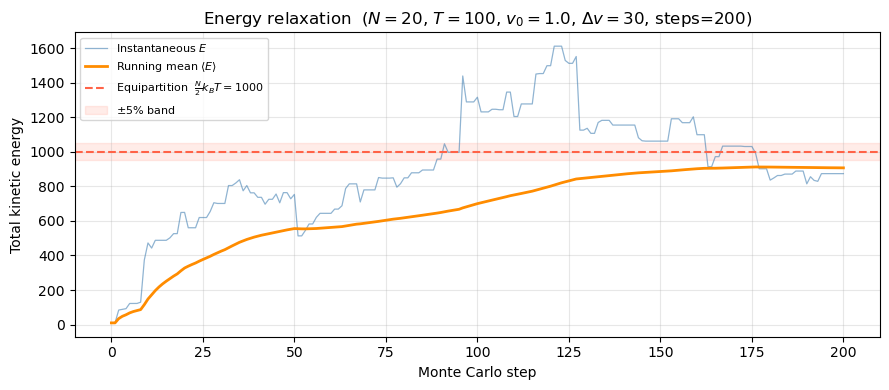

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 20          # number of particles
T = 100         # temperature (k_B = 1)
MC_steps = 200  # number of Monte Carlo steps — try increasing this!
v_init = 1.0    # initial velocity (note: E_init = 10 << E_equil = 1000)
beta = 1.0 / T

def attempt_move(v, idx, delta, beta):
    v_old = v[idx]
    v_trial = v_old + (2 * np.random.rand() - 1) * delta
    dE = 0.5 * (v_trial**2 - v_old**2)
    if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
        v[idx] = v_trial
        return 1
    return 0

# --- Part 1: Scan Δv to find ~50% acceptance ---
# Use a fully equilibrated system for the scan so acceptance reflects
# the true equilibrium distribution, not the cold initial state
deltas_to_test = [5, 15, 25, 30, 35]
accpt = []
print("Testing various Δv values for acceptance ratio:")
for delta in deltas_to_test:
    # Pre-equilibrate before measuring acceptance
    v_test = np.zeros(N)
    for _ in range(500):
        attempt_move(v_test, np.random.randint(0, N), delta, beta)
    accept_count = sum(
        attempt_move(v_test, np.random.randint(0, N), delta, beta)
        for _ in range(MC_steps)
    )
    acc_ratio = accept_count / MC_steps
    accpt.append(acc_ratio)
    print(f"  Δv = {delta:>3}: acceptance ≈ {acc_ratio:.3f}")

delta_opt = deltas_to_test[np.argmin(np.abs(np.array(accpt) - 0.5))]
print(f"\nSelected Δv = {delta_opt} (closest to 50% acceptance)")

# --- Part 2: Run simulation from cold start, track energy ---
v = np.full(N, v_init)
energy_trace = [0.5 * np.sum(v**2)]
accept_count = 0

for _ in range(MC_steps):
    i = np.random.randint(0, N)
    accept_count += attempt_move(v, i, delta_opt, beta)
    energy_trace.append(0.5 * np.sum(v**2))

energy_trace = np.array(energy_trace)

# Running mean
running_mean = np.cumsum(energy_trace) / np.arange(1, len(energy_trace) + 1)

# Report observables from the final state
accept_ratio         = accept_count / MC_steps
mean_KE_per_particle = np.mean(v**2) / 2.0
mean_velocity        = np.mean(v)
E_equil              = 0.5 * N * T

print(f"\nAcceptance ratio        ≈ {accept_ratio:.3f}")
print(f"Mean KE per particle    ≈ {mean_KE_per_particle:.2f}  (equipartition: {0.5*T:.1f})")
print(f"Mean velocity           ≈ {mean_velocity:.3f}  (expected: 0)")

# --- Part 3: Energy trace with running mean and tolerance band ---
tolerance = 0.05   # 5% band around E_equil
steps = np.arange(len(energy_trace))

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(steps, energy_trace, color='steelblue', lw=0.9, alpha=0.6, label='Instantaneous $E$')
ax.plot(steps, running_mean, color='darkorange', lw=2.0, label='Running mean $\\langle E \\rangle$')
ax.axhline(E_equil, color='tomato', ls='--', lw=1.5,
           label=f'Equipartition  $\\frac{{N}}{{2}}k_BT = {E_equil:.0f}$')
ax.axhspan(E_equil * (1 - tolerance), E_equil * (1 + tolerance),
           color='tomato', alpha=0.12, label=f'$\\pm{int(tolerance*100)}\\%$ band')

# Mark where running mean first enters and stays in the band
in_band = np.abs(running_mean - E_equil) / E_equil < tolerance
if in_band.any():
    eq_step = np.argmax(in_band)
    ax.axvline(eq_step, color='green', ls=':', lw=1.5,
               label=f'Running mean enters band (step {eq_step})')

ax.set_xlabel('Monte Carlo step')
ax.set_ylabel('Total kinetic energy')
ax.set_title(f'Energy relaxation  ($N={N}$, $T={T}$, $v_0={v_init}$, $\\Delta v={delta_opt}$, steps={MC_steps})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2. We might expect that the total energy of an ideal gas would remain constant since the particles do not interact with each other and hence cannot exchange energy directly. What is the initial value of the energy of the system? Does it remain constant? If it does not, explain how the energy changes. Explain why the measured mean particle velocity is zero even though the initial particle velocities are not zero.

Initial total energy  = 10.00
Mean sampled energy   = 1067.20  (equipartition: 1000.0)
Initial mean velocity = 1.000
Sampled mean velocity = -0.373  (expected: 0)
Sampled v_rms         = 10.331  (expected sqrt(T) = 10.000)


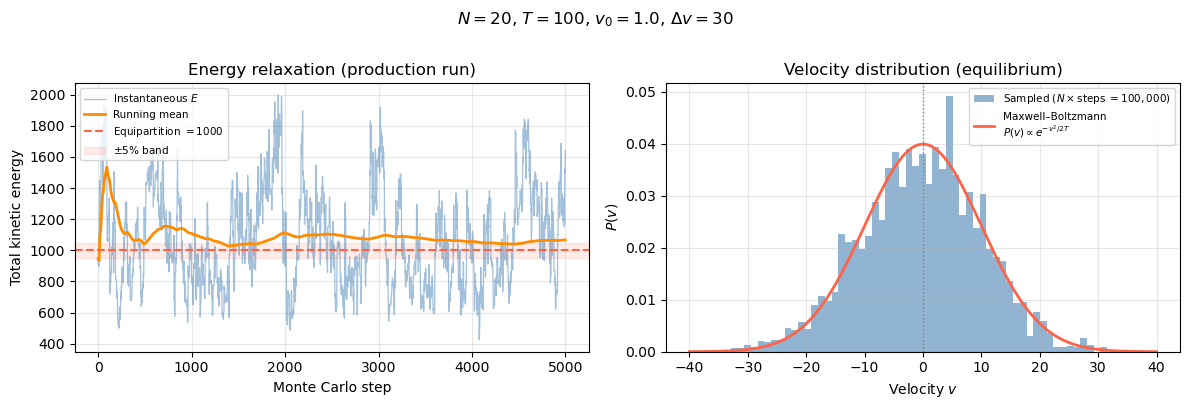

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
N            = 20     # number of particles
T            = 100    # temperature (k_B = 1)
beta         = 1.0 / T
delta_opt    = 30     # maximum velocity step (tuned for ~50% acceptance)
v_init       = 1.0    # initial velocity for all particles
steps_equil  = 500    # warmup steps (discarded)
steps_sample = 5000   # production steps from which we collect velocities
# ──────────────────────────────────────────────────────────────────────────────

# --- Run simulation, collecting all velocities after equilibration ---
v = np.full(N, v_init)
v_initial = v.copy()

# Equilibrate
for _ in range(steps_equil):
    attempt_move(v, np.random.randint(0, N), delta_opt, beta)

# Production: collect every particle's velocity at every step
energy_trace     = []
velocity_samples = []   # will have steps_sample * N entries total

for _ in range(steps_sample):
    i = np.random.randint(0, N)
    attempt_move(v, i, delta_opt, beta)
    energy_trace.append(0.5 * np.sum(v**2))
    velocity_samples.extend(v.tolist())   # all N velocities at this step

energy_trace     = np.array(energy_trace)
velocity_samples = np.array(velocity_samples)
running_mean     = np.cumsum(energy_trace) / np.arange(1, len(energy_trace) + 1)

print(f"Initial total energy  = {0.5*np.sum(v_initial**2):.2f}")
print(f"Mean sampled energy   = {energy_trace.mean():.2f}  (equipartition: {0.5*N*T:.1f})")
print(f"Initial mean velocity = {v_initial.mean():.3f}")
print(f"Sampled mean velocity = {velocity_samples.mean():.3f}  (expected: 0)")
print(f"Sampled v_rms         = {np.sqrt(np.mean(velocity_samples**2)):.3f}  "
      f"(expected sqrt(T) = {np.sqrt(T):.3f})")

E_equil   = 0.5 * N * T
tolerance = 0.05

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: energy trace
steps = np.arange(len(energy_trace))
ax1.plot(steps, energy_trace,  color='steelblue', lw=0.9, alpha=0.5, label='Instantaneous $E$')
ax1.plot(steps, running_mean,  color='darkorange', lw=2.0,            label='Running mean')
ax1.axhline(E_equil, color='tomato', ls='--', lw=1.5,
            label=f'Equipartition $= {E_equil:.0f}$')
ax1.axhspan(E_equil*(1-tolerance), E_equil*(1+tolerance),
            color='tomato', alpha=0.12, label=f'$\\pm{int(tolerance*100)}\\%$ band')
ax1.set_xlabel('Monte Carlo step')
ax1.set_ylabel('Total kinetic energy')
ax1.set_title('Energy relaxation (production run)')
ax1.legend(fontsize=7.5)
ax1.grid(True, alpha=0.3)

# Right: velocity distribution
v_range = np.linspace(-4*np.sqrt(T), 4*np.sqrt(T), 300)
P_MB    = np.exp(-v_range**2 / (2*T)) / np.sqrt(2*np.pi*T)

ax2.hist(velocity_samples, bins=60, density=True, alpha=0.6,
         color='steelblue', label=f'Sampled ($N\\times$steps $={len(velocity_samples):,}$)')
ax2.plot(v_range, P_MB, 'tomato', lw=2.0,
         label=f'Maxwell–Boltzmann\n$P(v)\\propto e^{{-v^2/2T}}$')
ax2.axvline(0, color='gray', ls=':', lw=1)
ax2.set_xlabel('Velocity $v$')
ax2.set_ylabel('$P(v)$')
ax2.set_title('Velocity distribution (equilibrium)')
ax2.legend(fontsize=7.5)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'$N={N}$, $T={T}$, $v_0={v_init}$, $\\Delta v={delta_opt}$', y=1.01)
plt.tight_layout()
plt.show()

3. What is a simple criterion for “thermal equilibrium”? Estimate the number of Monte Carlo steps per particle necessary for the system to reach thermal equilibrium. What choice of the initial velocities allows the system to reach thermal equilibrium at temperature $T$ as quickly as possible?

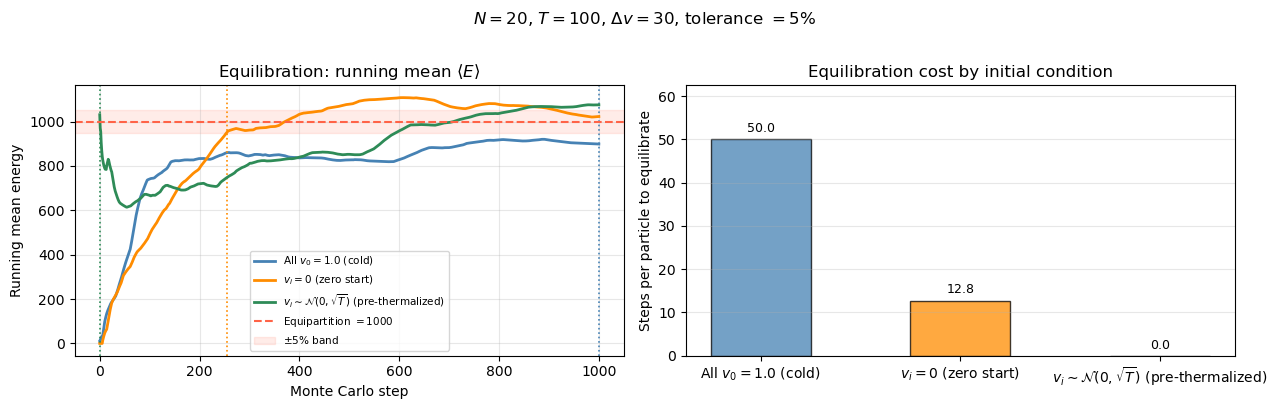

Steps per particle to equilibrate:
  All v_0 = 1.0 (cold)                         : 50.0
  v_i = 0 (zero start)                         : 12.8
  v_i \sim \mathcal{N}(0,\sqrt{T}) (pre-thermalized): 0.0 ← pre-thermalized


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
N          = 20      # number of particles
T          = 100     # temperature (k_B = 1)
beta       = 1.0 / T
delta_opt  = 30      # ~50% acceptance at equilibrium (from Question 1)
v_init     = 1.0     # cold-start velocity (used in scenarios 1 and 2)
steps_total = 1000   # total MC steps
tolerance  = 0.05    # fraction band around E_equil for equilibration criterion
# ──────────────────────────────────────────────────────────────────────────────

E_equil = 0.5 * N * T

# Three initial conditions to compare
scenarios = {
    f'All $v_0 = {v_init}$ (cold)' : np.full(N, v_init),
    '$v_i = 0$ (zero start)'       : np.zeros(N),
    '$v_i \\sim \\mathcal{N}(0,\\sqrt{T})$ (pre-thermalized)' : np.random.normal(0, np.sqrt(T), N),
}
colors = ['steelblue', 'darkorange', 'seagreen']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

eq_steps = {}
for (label, v0), color in zip(scenarios.items(), colors):
    v = v0.copy()
    energy_trace = [0.5 * np.sum(v**2)]

    for _ in range(steps_total):
        attempt_move(v, np.random.randint(0, N), delta_opt, beta)
        energy_trace.append(0.5 * np.sum(v**2))

    energy_trace = np.array(energy_trace)
    running_mean = np.cumsum(energy_trace) / np.arange(1, len(energy_trace) + 1)

    # Find first step where running mean enters and stays in tolerance band
    in_band = np.abs(running_mean - E_equil) / E_equil < tolerance
    eq_step = int(np.argmax(in_band)) if in_band.any() else steps_total
    eq_steps[label] = eq_step

    steps = np.arange(len(energy_trace))
    ax1.plot(steps, running_mean, color=color, lw=2.0, label=label)
    ax1.axvline(eq_step, color=color, ls=':', lw=1.2)

ax1.axhline(E_equil, color='tomato', ls='--', lw=1.5,
            label=f'Equipartition $= {E_equil:.0f}$')
ax1.axhspan(E_equil*(1-tolerance), E_equil*(1+tolerance),
            color='tomato', alpha=0.12, label=f'$\\pm{int(tolerance*100)}\\%$ band')
ax1.set_xlabel('Monte Carlo step')
ax1.set_ylabel('Running mean energy')
ax1.set_title('Equilibration: running mean $\\langle E \\rangle$')
ax1.legend(fontsize=7.5)
ax1.grid(True, alpha=0.3)

# Right panel: steps per particle to equilibrate
labels       = list(eq_steps.keys())
steps_pp     = [eq_steps[l] / N for l in labels]
bars = ax2.bar(labels, steps_pp, color=colors, alpha=0.75, edgecolor='k', width=0.5)
ax2.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax2.set_ylabel('Steps per particle to equilibrate')
ax2.set_title('Equilibration cost by initial condition')
ax2.set_ylim(0, max(steps_pp) * 1.25)
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'$N={N}$, $T={T}$, $\\Delta v={delta_opt}$, tolerance $={int(tolerance*100)}\\%$', y=1.01)
plt.tight_layout()
plt.show()

print("Steps per particle to equilibrate:")
for label, sp in zip(labels, steps_pp):
    marker = " ← pre-thermalized" if "mathcal" in label else ""
    print(f"  {label.replace('$','').replace('\\\\',''):45s}: {sp:.1f}{marker}")

4. Compute the mean energy per particle for $T=10$, $100$, $200$, $300$ and $400$. In order to compute the averages after the system has reached thermal equilibrium, start measuring only after equilibrium has been achieved. Increase the number of Monte Carlo steps until the desired averages do not change appreciably. What is the approximate number of warmup steps for $N=10$ and $T=100$, and for $N=40$ and $T=100$? If the number of warmup steps is different in the two cases, explain the reason for this difference.

T=  10: <E/N> = 5.218   (equipartition: 5.000)
T= 100: <E/N> = 47.703   (equipartition: 50.000)
T= 200: <E/N> = 95.243   (equipartition: 100.000)
T= 300: <E/N> = 154.169   (equipartition: 150.000)
T= 400: <E/N> = 195.691   (equipartition: 200.000)


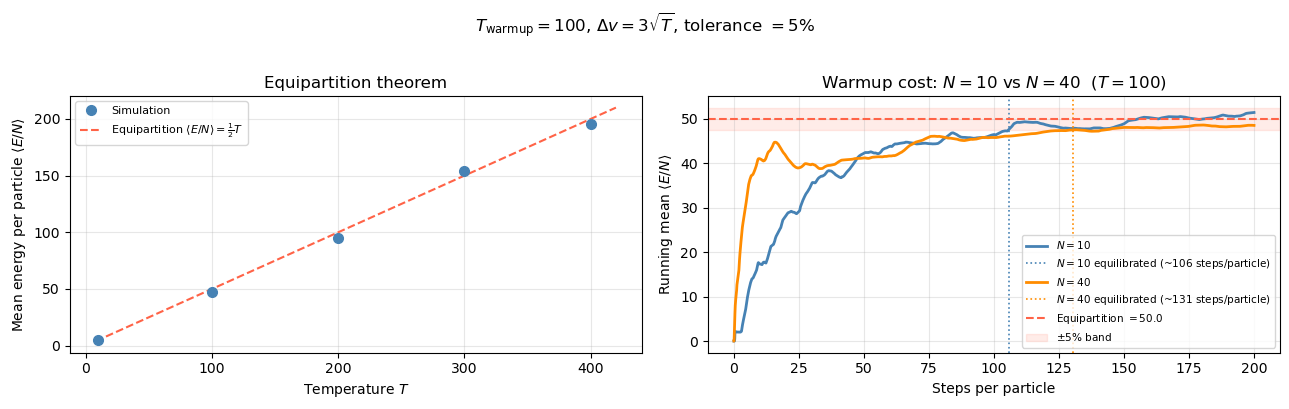

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
T_list        = [10, 100, 200, 300, 400]  # Part 4A: temperatures to scan
N_list        = [10, 40 ]                  # Part 4B: system sizes to compare
T_warmup      = 100                       # temperature for warmup comparison
warmup_steps  = 1000                      # warmup steps for Part 4A
measure_steps = 5000                      # production steps for Part 4A
max_steps_pp  = 200                       # steps per particle for Part 4B traces
tolerance     = 0.05                      # equilibration band (±5%)
# ──────────────────────────────────────────────────────────────────────────────

# ── Part 4A: mean energy per particle vs temperature ──────────────────────────
mean_E_per_particle = []

for T in T_list:
    beta  = 1.0 / T
    delta = 3 * np.sqrt(T)   # heuristic: ~50% acceptance at equilibrium

    v = np.zeros(N_list[1])  # use N=40 throughout Part 4A for consistency
    N = len(v)

    for _ in range(warmup_steps):
        attempt_move(v, np.random.randint(0, N), delta, beta)

    E_sum = 0.0
    for _ in range(measure_steps):
        attempt_move(v, np.random.randint(0, N), delta, beta)
        E_sum += 0.5 * np.sum(v**2)

    mean_E = E_sum / measure_steps / N
    mean_E_per_particle.append(mean_E)
    print(f"T={T:>4}: <E/N> = {mean_E:.3f}   (equipartition: {0.5*T:.3f})")

# ── Part 4B: warmup traces for N=10 vs N=40 at fixed T ───────────────────────
colors = ['steelblue', 'darkorange']
warmup_traces = {}

for N, color in zip(N_list, colors):
    beta  = 1.0 / T_warmup
    delta = 3 * np.sqrt(T_warmup)
    v     = np.zeros(N)
    E_equil = 0.5 * N * T_warmup

    energy_trace = [0.5 * np.sum(v**2)]
    for _ in range(max_steps_pp * N):
        attempt_move(v, np.random.randint(0, N), delta, beta)
        energy_trace.append(0.5 * np.sum(v**2))

    energy_trace  = np.array(energy_trace)
    running_mean  = np.cumsum(energy_trace) / np.arange(1, len(energy_trace) + 1)
    steps_pp      = np.arange(len(energy_trace)) / N   # x-axis in steps per particle

    # Equilibration point using running mean criterion
    in_band = np.abs(running_mean - E_equil) / E_equil < tolerance
    eq_step_pp = float(np.argmax(in_band)) / N if in_band.any() else max_steps_pp

    warmup_traces[N] = dict(steps_pp=steps_pp, running_mean=running_mean / N,
                            eq_step_pp=eq_step_pp, color=color,
                            E_equil_pp=0.5 * T_warmup)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: <E/N> vs T with equipartition line
T_theory = np.linspace(min(T_list)*0.8, max(T_list)*1.05, 200)
ax1.plot(T_list, mean_E_per_particle, 'o', color='steelblue',
         ms=7, zorder=3, label='Simulation')
ax1.plot(T_theory, 0.5 * T_theory, 'tomato', lw=1.5, ls='--',
         label='Equipartition $\\langle E/N \\rangle = \\frac{1}{2}T$')
ax1.set_xlabel('Temperature $T$')
ax1.set_ylabel('Mean energy per particle $\\langle E/N \\rangle$')
ax1.set_title('Equipartition theorem')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: warmup traces in steps per particle for N=10 and N=40
for N, d in warmup_traces.items():
    ax2.plot(d['steps_pp'], d['running_mean'], color=d['color'],
             lw=2.0, label=f'$N={N}$')
    ax2.axvline(d['eq_step_pp'], color=d['color'], ls=':', lw=1.2,
                label=f'$N={N}$ equilibrated (~{d["eq_step_pp"]:.0f} steps/particle)')

ax2.axhline(0.5 * T_warmup, color='tomato', ls='--', lw=1.5,
            label=f'Equipartition $= {0.5*T_warmup:.1f}$')
ax2.axhspan(0.5*T_warmup*(1-tolerance), 0.5*T_warmup*(1+tolerance),
            color='tomato', alpha=0.12, label=f'$\\pm{int(tolerance*100)}\\%$ band')
ax2.set_xlabel('Steps per particle')
ax2.set_ylabel('Running mean $\\langle E/N \\rangle$')
ax2.set_title(f'Warmup cost: $N=10$ vs $N=40$  ($T={T_warmup}$)')
ax2.legend(fontsize=7.5)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'$T_{{\\rm warmup}}={T_warmup}$, $\\Delta v = 3\\sqrt{{T}}$, '
             f'tolerance $={int(tolerance*100)}\\%$', y=1.01)
plt.tight_layout()
plt.show()

Running N=10 (200 trials)...
  median = 6.5  mean = 8.8  std = 7.2  frac_capped = 0.00
Running N=40 (200 trials)...
  median = 4.2  mean = 4.9  std = 2.5  frac_capped = 0.00
Running N=100 (200 trials)...
  median = 4.7  mean = 5.1  std = 1.8  frac_capped = 0.00
Running N=1000 (200 trials)...
  median = 5.4  mean = 5.6  std = 0.9  frac_capped = 0.00


C:\Users\tomke\AppData\Local\Temp\ipykernel_24200\275769833.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=labels, patch_artist=True, notch=True,


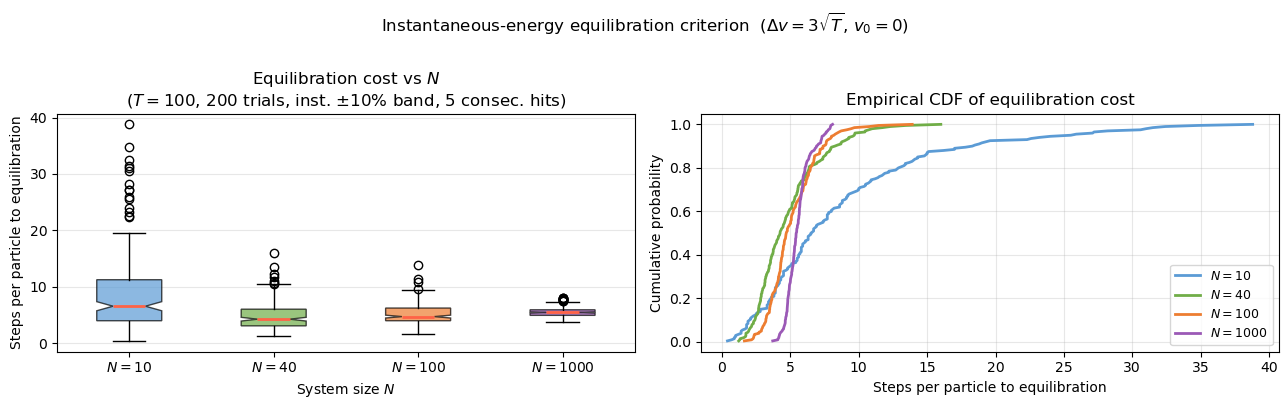

In [33]:
# ── Parameters ────────────────────────────────────────────────────────────────
N_values      = [10, 40, 100, 1000]   # system sizes to compare
T_equil       = 100                   # temperature
n_trials      = 200                   # simulations per N
max_steps_pp  = 500                   # cap (steps per particle) to avoid infinite loops
inst_tol      = 0.10                  # ±10% band on instantaneous E/N
n_consec      = 5                     # consecutive steps inside band to call "equilibrated"
# ──────────────────────────────────────────────────────────────────────────────

beta_eq  = 1.0 / T_equil
delta_eq = 3 * np.sqrt(T_equil)
E_target = 0.5 * T_equil             # equipartition: <E/N> = T/2

rng = np.random.default_rng(42)

def first_equilibration_step_pp(N, beta, delta, E_target, tol, n_consec, max_spp, rng):
    """
    Run Metropolis on N particles from v=0.
    Return the steps-per-particle at which the instantaneous E/N
    first stays within ±tol of E_target for n_consec consecutive steps.
    Returns max_spp if not reached.
    """
    v = np.zeros(N)
    consec = 0
    total_steps = int(max_spp * N)

    for step in range(1, total_steps + 1):
        i = rng.integers(0, N)
        v_old   = v[i]
        v_trial = v_old + (2 * rng.random() - 1) * delta
        dE = 0.5 * (v_trial**2 - v_old**2)
        if dE <= 0 or rng.random() < np.exp(-beta * dE):
            v[i] = v_trial

        E_pp = 0.5 * np.sum(v**2) / N
        if abs(E_pp - E_target) / E_target < tol:
            consec += 1
            if consec >= n_consec:
                return (step - n_consec + 1) / N   # first entry into the band
        else:
            consec = 0

    return max_spp   # cap: never equilibrated

# ── Run trials ────────────────────────────────────────────────────────────────
results = {}
for N in N_values:
    print(f"Running N={N} ({n_trials} trials)...", flush=True)
    eq_steps = [
        first_equilibration_step_pp(N, beta_eq, delta_eq, E_target,
                                    inst_tol, n_consec, max_steps_pp, rng)
        for _ in range(n_trials)
    ]
    results[N] = np.array(eq_steps)
    print(f"  median = {np.median(eq_steps):.1f}  mean = {np.mean(eq_steps):.1f}  "
          f"std = {np.std(eq_steps):.1f}  frac_capped = {np.mean(np.array(eq_steps)==max_steps_pp):.2f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: box plot of equilibration steps/particle for each N
data    = [results[N] for N in N_values]
labels  = [f'$N={N}$' for N in N_values]
bp = axes[0].boxplot(data, labels=labels, patch_artist=True, notch=True,
                     medianprops=dict(color='tomato', lw=2))
colors_box = ['#5b9bd5', '#70ad47', '#ed7d31', '#9b59b6']
for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

axes[0].set_xlabel('System size $N$')
axes[0].set_ylabel('Steps per particle to equilibration')
axes[0].set_title(f'Equilibration cost vs $N$\n'
                  f'($T={T_equil}$, {n_trials} trials, '
                  f'inst. $\\pm{int(inst_tol*100)}\\%$ band, {n_consec} consec. hits)')
axes[0].grid(True, alpha=0.3, axis='y')

# Right: empirical CDFs — reveals the full shape of the distribution
for N, color in zip(N_values, colors_box):
    sorted_eq = np.sort(results[N])
    cdf = np.arange(1, len(sorted_eq) + 1) / len(sorted_eq)
    axes[1].plot(sorted_eq, cdf, color=color, lw=2, label=f'$N={N}$')

axes[1].set_xlabel('Steps per particle to equilibration')
axes[1].set_ylabel('Cumulative probability')
axes[1].set_title('Empirical CDF of equilibration cost')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Instantaneous-energy equilibration criterion  '
             f'($\\Delta v = 3\\sqrt{{T}}$, $v_0=0$)',
             y=1.01)
plt.tight_layout()
plt.show()

5. Compute the probability $P(E),dE$ for the system of $N$ particles to have a total energy between $E$ and $E+dE$. Do you expect $P(E)$ to be proportional to $e^{-\beta E}$? Plot $P(E)$ as a function of $E$ and describe the qualitative behavior of $P(E)$. Does the plot of $\ln P(E)$ yield a straight line?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as gamma_func

# ── Parameters ────────────────────────────────────────────────────────────────
N            = 20       # number of particles (try changing to see distribution sharpen)
T            = 100      # temperature (k_B = 1)
beta         = 1.0 / T
delta_opt    = 30       # ~50% acceptance at equilibrium (from Question 1)
v_init       = 1.0      # initial velocity
warmup_steps = 1000     # discarded steps
num_samples  = 100000   # production steps
# ──────────────────────────────────────────────────────────────────────────────

# Equilibrate
v = np.full(N, v_init)
for _ in range(warmup_steps):
    attempt_move(v, np.random.randint(0, N), delta_opt, beta)

# Collect total energy samples
energy_samples = []
for _ in range(num_samples):
    attempt_move(v, np.random.randint(0, N), delta_opt, beta)
    energy_samples.append(0.5 * np.sum(v**2))

energy_samples = np.array(energy_samples)

# Analytical Gamma distribution
# P(E) = beta^(N/2) / Gamma(N/2) * E^(N/2-1) * exp(-beta*E)
E_theory = np.linspace(energy_samples.min() * 0.5,
                       energy_samples.max() * 1.2, 500)
P_theory = (beta**(N/2) / gamma_func(N/2)) * E_theory**(N/2 - 1) * np.exp(-beta * E_theory)

# Simple Boltzmann P(E) ∝ exp(-beta*E), normalized over same range
P_boltzmann_raw = np.exp(-beta * E_theory)
# Normalize to unit area over the plotted range
dE = E_theory[1] - E_theory[0]
P_boltzmann = P_boltzmann_raw / (np.sum(P_boltzmann_raw) * dE)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: P(E) histogram vs Gamma and pure Boltzmann
ax1.hist(energy_samples, bins=80, density=True, alpha=0.5,
         color='steelblue', label='Simulation')
ax1.plot(E_theory, P_theory, 'tomato', lw=2.0,
         label=f'Gamma distribution\n'
               f'$P(E)\\propto E^{{N/2-1}}e^{{-\\beta E}}$')
ax1.plot(E_theory, P_boltzmann, 'k--', lw=1.5,
         label='Pure Boltzmann $e^{-\\beta E}$ (normalized)')
ax1.axvline(0.5 * N * T, color='gray', ls=':', lw=1.2,
            label=f'Equipartition $E^*={0.5*N*T:.0f}$')
ax1.set_xlabel('Total energy $E$')
ax1.set_ylabel('$P(E)$')
ax1.set_title('Total energy distribution')
ax1.legend(fontsize=7.5)
ax1.grid(True, alpha=0.3)

# Right: ln P(E) — should be curved, not straight
hist, bin_edges = np.histogram(energy_samples, bins=80, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
mask = hist > 0

ax2.plot(bin_centers[mask], np.log(hist[mask]), 'o', color='steelblue',
         ms=4, alpha=0.7, label='Simulation $\\ln P(E)$')
ax2.plot(E_theory, np.log(P_theory), 'tomato', lw=2.0,
         label='Gamma: $\\ln P = (N/2-1)\\ln E - \\beta E + \\rm{const}$')
ax2.plot(E_theory, np.log(P_boltzmann), 'k--', lw=1.5,
         label='Pure Boltzmann: $\\ln P = -\\beta E + \\rm{const}$')
ax2.set_xlabel('Total energy $E$')
ax2.set_ylabel('$\\ln P(E)$')
ax2.set_title('$\\ln P(E)$ — not a straight line for $N > 2$')
ax2.legend(fontsize=7.5)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'$N={N}$, $T={T}$, $\\beta={beta}$, samples$={num_samples:,}$', y=1.01)
plt.tight_layout()
plt.show()

# Print summary statistics vs analytical expectations
E_mean_theory = N / (2 * beta)          # = N*T/2
E_var_theory  = N / (2 * beta**2)       # = N*T^2/2
print(f"<E> simulation : {energy_samples.mean():.2f}   theory: {E_mean_theory:.2f}")
print(f"std(E) simulation: {energy_samples.std():.2f}   "
      f"theory: {np.sqrt(E_var_theory):.2f}")
print(f"Relative width σ/<E> = {energy_samples.std()/energy_samples.mean():.3f}   "
      f"theory: {1/np.sqrt(N/2):.3f}   (∝ 1/√N)")

For a single particle in 1D, the energy is $E_i = \frac{1}{2}v_i^2$ and the Boltzmann weight gives the single-particle distribution $P(E_i) \propto e^{-\beta E_i}$. One might expect the total energy $E = \sum_i E_i$ to follow $P(E) \propto e^{-\beta E}$ as well. This would be the case if the system had only one degree of freedom — but with $N$ particles there are $N$ independent degrees of freedom, and we need to count the number of microstates consistent with a given total energy $E$.

The total energy distribution is the convolution of $N$ independent single-particle distributions. For $N$ particles in 1D with $k_B = m = 1$, the result is a Gamma distribution:

$$P(E) = \frac{\beta^{N/2}}{\Gamma(N/2)}\, E^{N/2-1}\, e^{-\beta E}$$

The prefactor $E^{N/2-1}$ is the density of states — it counts the number of ways to distribute total energy $E$ among $N$ particles, and grows with $E$ for $N > 2$. This competing factor means $P(E)$ is not simply proportional to $e^{-\beta E}$, and $\ln P(E)$ is therefore not a straight line:

$$\ln P(E) = \mathrm{const} + \left(\frac{N}{2} - 1\right)\ln E - \beta E$$

The distribution is peaked at $E^* = \frac{N-2}{2\beta} \approx \frac{N}{2}k_BT$ for large $N$, consistent with equipartition. For large $N$ the peak sharpens and $P(E)$ approaches a Gaussian by the central limit theorem — the relative width $\sigma_E / \langle E \rangle \propto 1/\sqrt{N}$ vanishes. The plot below shows both $P(E)$ and $\ln P(E)$ with the analytical Gamma distribution overlaid.

6. Compute the heat capacity of this 1D gas.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
N             = 20                        # number of particles
T_values      = np.arange(10, 111, 10)   # T = 10, 20, ..., 110
warmup_steps  = 1000                      # discarded steps per temperature
measure_steps = 10000                     # production steps per temperature
# ──────────────────────────────────────────────────────────────────────────────

mean_E   = np.zeros(len(T_values))   # <E>   at each T
mean_E2  = np.zeros(len(T_values))   # <E²>  at each T
std_E    = np.zeros(len(T_values))   # std of sampled energies (for error bars)

for k, T in enumerate(T_values):
    beta  = 1.0 / T
    delta = 3 * np.sqrt(T)

    # Equilibrate from zero
    v = np.zeros(N)
    for _ in range(warmup_steps):
        attempt_move(v, np.random.randint(0, N), delta, beta)

    # Production: accumulate <E> and <E²>
    E_samples = np.empty(measure_steps)
    for s in range(measure_steps):
        attempt_move(v, np.random.randint(0, N), delta, beta)
        E_samples[s] = 0.5 * np.sum(v**2)

    mean_E[k]  = E_samples.mean()
    mean_E2[k] = (E_samples**2).mean()
    std_E[k]   = E_samples.std() / np.sqrt(measure_steps)   # std error on <E>

    print(f"T={T:>4}: <E/N> = {mean_E[k]/N:.3f}   "
          f"(equipartition: {0.5*T:.3f})")

# ── Method 1: C_V from linear fit to <E> vs T ─────────────────────────────────
coeffs   = np.polyfit(T_values, mean_E, 1)          # slope = C_V (total)
C_fit    = coeffs[0]                                 # total heat capacity
C_fit_pp = C_fit / N                                 # per particle

# ── Method 2: C_V from energy fluctuations <ΔE²>/T² ──────────────────────────
C_fluct    = (mean_E2 - mean_E**2) / T_values**2    # total C_V at each T
C_fluct_pp = C_fluct / N                             # per particle

print(f"\nMethod 1 (slope of <E> vs T):       C_V/N = {C_fit_pp:.4f}   "
      f"(theory: 0.5000)")
print(f"Method 2 (fluctuations, mean over T): C_V/N = {C_fluct_pp.mean():.4f}   "
      f"(theory: 0.5000)")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: <E/N> vs T with linear fit and equipartition line
T_theory = np.linspace(T_values[0] * 0.8, T_values[-1] * 1.05, 200)
ax1.errorbar(T_values, mean_E / N, yerr=std_E / N,
             fmt='o', color='steelblue', ms=5, capsize=3, label='Simulation')
ax1.plot(T_theory, 0.5 * T_theory, 'tomato', lw=1.5, ls='--',
         label='Equipartition $\\langle E/N \\rangle = \\frac{1}{2}T$')
ax1.plot(T_theory, np.polyval(coeffs, T_theory) / N, 'darkorange', lw=1.5, ls='-.',
         label=f'Linear fit  slope $= C_V/N = {C_fit_pp:.3f}$')
ax1.set_xlabel('Temperature $T$')
ax1.set_ylabel('Mean energy per particle $\\langle E/N \\rangle$')
ax1.set_title('Mean energy vs temperature')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: C_V/N from both methods vs T
ax2.plot(T_values, C_fluct_pp, 'o-', color='steelblue', ms=5,
         label='Fluctuations $\\langle\\Delta E^2\\rangle / T^2 N$')
ax2.axhline(C_fit_pp, color='darkorange', lw=1.5, ls='-.',
            label=f'Linear fit slope $= {C_fit_pp:.3f}$')
ax2.axhline(0.5, color='tomato', lw=1.5, ls='--',
            label='Equipartition $C_V/N = \\frac{1}{2}$')
ax2.set_xlabel('Temperature $T$')
ax2.set_ylabel('$C_V / N$')
ax2.set_title('Heat capacity per particle')
ax2.set_ylim(0, 1.2)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'$N={N}$,  $\\Delta v = 3\\sqrt{{T}}$,  '
             f'warmup$={warmup_steps}$,  samples$={measure_steps}$', y=1.01)
plt.tight_layout()
plt.show()

# Appendix A: Converting Units

In our simulations, we use **dimensionless units** by setting the Boltzmann constant $k_B = 1$ and particle mass $m = 1$. To interpret our results in **SI units**, we need to reintroduce physical constants. Here's how:

---

## Step 1: Reintroduce $k_B$ to recover energy in joules

The Boltzmann constant in SI units is:
$$
k_B = 1.380649 \times 10^{-23} \ \text{J/K}
$$
In the simulation, energy already carries the temperature dependence. Setting $k_B=1$ means our simulation energies are measured in units of joules per $k_B$ (or just Kelvin). To convert to SI energy units, we need to restore $k_b$:
$$
\langle E \rangle_{\text{SI}} = \langle E \rangle_{\text{sim}} \cdot k_B
$$
For example, if your simulation reports $\langle E \rangle_{\text{sim}} = 0.5$ at $T = 300 \ \text{K}$, then:
$$
\langle E \rangle_{\text{SI}} = 0.5 \cdot 1.38 \times 10^{-23} \approx 6.9 \times 10^{-22} \ \text{J}
$$

---

## Step 2: Convert simulation velocities to m/s

In simulation units, we set the mass $m = 1$, and kinetic energy is computed as:
$$
E = \frac{1}{2} v^2
$$
To convert simulation velocities to physical velocities in SI units, use:
$$
v_{\text{SI}} = v_{\text{sim}} \cdot \sqrt{\frac{k_B T}{m}}
$$
For example, if you are simulating helium atoms (with $m = 6.64 \times 10^{-27} \ \text{kg}$) at $T = 100 \ \text{K}$, then the velocity unit is:
$$
\sqrt{\frac{1.38 \times 10^{-23} \cdot 100}{6.64 \times 10^{-27}}} \approx 456 \ \text{m/s}
$$
So a simulated particle with $v_{\text{sim}} = 1$ corresponds to:
$$
v_{\text{SI}} \approx 456 \ \text{m/s}
$$

---

## Step 3: Convert heat capacity to SI units

In the simulation, the heat capacity per particle is typically:
$$
C_{\text{sim}} = \frac{1}{2}
$$
To convert this to SI units, multiply by $k_B$:
$$
C_{\text{SI}} = C_{\text{sim}} \cdot k_B = \frac{1}{2} \cdot 1.38 \times 10^{-23} \ \text{J/K}
$$
For a system of $N$ particles, total heat capacity is:
$$
C_{\text{total}} = \frac{N}{2} \cdot k_B
$$
For example, if $N = 20$, then:
$$
C_{\text{total}} \approx 10 \cdot 1.38 \times 10^{-23} = 1.38 \times 10^{-22} \ \text{J/K}
$$

---

## Summary

- Multiply energy by $k_B T$ to get joules.
- Multiply velocity by $\sqrt{k_B T / m}$ to get m/s.
- Multiply heat capacity by $k_B$ to get J/K.

These conversions allow you to interpret your dimensionless simulation results in real-world physical units.


# Appendix B: The Fluctuation-Dissipation Theorem for Energy

In Question 6 we computed the heat capacity $C_V$ two ways: (1) from the slope of $\langle E \rangle$ vs $T$, and (2) from the variance of energy fluctuations $\langle \Delta E^2 \rangle / T^2$ — and found they agree. This is not a coincidence. Here we derive the identity connecting them directly from the partition function.

## Setup

In the canonical ensemble the partition function is:
$$Z = \sum_s e^{-\beta E_s}$$
where the sum runs over all microstates $s$ and $\beta = 1/k_BT$. All thermodynamic quantities follow from derivatives of $\ln Z$.

## Mean energy

The mean energy is:
$$\langle E \rangle = \frac{1}{Z}\sum_s E_s\, e^{-\beta E_s}$$
We can write this compactly as a derivative of $\ln Z$ with respect to $\beta$:
$$\langle E \rangle = -\frac{\partial \ln Z}{\partial \beta}$$
To verify: $\partial \ln Z / \partial \beta = (1/Z)\,\partial Z/\partial \beta = (1/Z)\sum_s(-E_s)e^{-\beta E_s} = -\langle E \rangle$. ✓

## Mean square energy

Differentiating $\langle E \rangle$ once more with respect to $\beta$:
$$\frac{\partial \langle E \rangle}{\partial \beta} = -\frac{\partial^2 \ln Z}{\partial \beta^2}$$
Expanding the left side directly:
$$\frac{\partial \langle E \rangle}{\partial \beta} = \frac{\partial}{\partial \beta}\left(\frac{\sum_s E_s e^{-\beta E_s}}{Z}\right) = \frac{\sum_s (-E_s^2)e^{-\beta E_s}}{Z} - \frac{\sum_s E_s e^{-\beta E_s}}{Z} \cdot \frac{\sum_s (-E_s) e^{-\beta E_s}}{Z}$$
$$= -\langle E^2 \rangle + \langle E \rangle^2 = -\langle \Delta E^2 \rangle$$
where $\langle \Delta E^2 \rangle \equiv \langle E^2 \rangle - \langle E \rangle^2$ is the variance of the energy. So:
$$\langle \Delta E^2 \rangle = -\frac{\partial \langle E \rangle}{\partial \beta}$$

## Connecting to heat capacity

The heat capacity at constant volume is defined as:
$$C_V \equiv \frac{\partial \langle E \rangle}{\partial T}$$
Using the chain rule $\partial/\partial T = (\partial \beta/\partial T)\,\partial/\partial\beta = (-1/k_BT^2)\,\partial/\partial\beta$:
$$C_V = -\frac{1}{k_BT^2}\frac{\partial \langle E \rangle}{\partial \beta} = \frac{\langle \Delta E^2 \rangle}{k_B T^2}$$

This is the **fluctuation-dissipation relation for energy**:

$$\boxed{C_V = \frac{\langle \Delta E^2 \rangle}{k_B T^2}}$$

It states that the heat capacity (a macroscopic response function measuring how much energy the system absorbs per degree of temperature increase) is entirely determined by the spontaneous equilibrium fluctuations of the energy. No external perturbation is needed; the system's own thermal noise encodes its response.

## Verification for the 1D ideal gas

For our 1D ideal gas of $N$ particles with $k_B = 1$ and $m = 1$, the total energy is $E = \sum_{i=1}^N \frac{1}{2}v_i^2$. Each particle contributes one quadratic degree of freedom, so by equipartition $\langle E \rangle = \frac{N}{2}T$, giving:
$$C_V = \frac{\partial \langle E \rangle}{\partial T} = \frac{N}{2}$$
From the fluctuation side, the total energy follows a Gamma distribution with variance $\langle \Delta E^2 \rangle = N/(2\beta^2) = \frac{N}{2}T^2$, so:
$$\frac{\langle \Delta E^2 \rangle}{T^2} = \frac{N}{2} = C_V \checkmark$$
Both methods give $C_V/N = \frac{1}{2}$, consistent with the simulation results in Question 6.

## Significance

This result is an instance of a much more general principle in statistical mechanics: **equilibrium fluctuations determine linear response**. The same structure appears throughout physics; the fluctuation-dissipation theorem relates, for example, the diffusion coefficient to velocity autocorrelations (Einstein relation), electrical conductivity to current fluctuations (Nyquist theorem), and magnetic susceptibility to magnetization fluctuations. In the context of the Ising model, the analogous identity $\chi = \langle \Delta M^2 \rangle / k_BT$ for the magnetic susceptibility will allow us to detect the phase transition through a dramatic divergence in magnetization fluctuations near the critical temperature.